# *Chapter 3*<br> Errors & Uncertainties in Computations

| | | |
|:---:|:---:|:---:|
| ![image](Figs/Cover.png)|[From **COMPUTATIONAL PHYSICS**, 3rd Ed, 2015](http://physics.oregonstate.edu/~rubin/Books/CPbook/index.html) <br>RH Landau, MJ Paez, and CC Bordeianu (deceased) <br>Copyrights: <br> [Wiley-VCH, Berlin;](http://www.wiley-vch.de/publish/en/books/ISBN3-527-41315-4/) and [Wiley & Sons, New York](http://www.wiley.com/WileyCDA/WileyTitle/productCd-3527413154.html)<br>  R Landau, Oregon State Unv, <br>MJ Paez, Univ Antioquia,<br> C Bordeianu, Univ Bucharest, 2015.<br> Support by National Science Foundation.|![image](Figs/BackCover.png)|

> To err is human, to forgive divine. - Alexander Pope

**3 Errors & Uncertainties in Computations**<br>
[3.1 Types of Errors (Theory)](#3.1)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[3.1.1 Model for Disaster: Subtractive
Cancellation](#3.1.1)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[3.1.2 Subtractive Cancellation Exercises](#3.1.2)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[3.1.3 Round-off Errors](#3.1.3)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[3.1.4 Round-off Error Accumulation](#3.1.4)<br>
[3.2 Error in Bessel Functions (Problem)](#3.2)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[3.2.1 Numerical Recursion (Method)](#3.2.1)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[3.2.2 Recursion Relations Assessment](#3.2.2)<br>
[3.3 Experimental Error Investigation](#3.3)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[3.3.1 Error Assessment](#3.3.1)<br> 

*Whether you are careful or not, errors and uncertainties are part of
computation. Some errors are the ones that humans inevitably make, but
some are introduced by the computer. Computer errors arise because of
the limited *precision* with which computers store numbers or because
algorithms or models can fail. Although it stifles creativity to keep
thinking ’error’ when approaching a computation, it certainly is a waste
of time, and possibly harmful, to work with results that are meaningless
(’garbage’) because of errors. In this chapter we examine some of the
errors and uncertainties that may occur in computations. Although we do
not keep repeating a mantra about watching for errors, the lessons of
this chapter apply to all other chapters as well.*

** This Chapter’s Lecture, Slide Web Links, Applets & Animations**

| | |
|---|---|
|[All Lectures](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/index.html)|[![anything](Figs/RHLlectureMod4.png)](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/index.html)|

| *Lecture (Flash)*| *Slides* | *Sections*|
|- - -|:- - -:|:- - -:|
|[Errors](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Modules/Errors/Errors.html)|[pdf Slides](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/Lectures/Slides/Slides_NoAnimate_pdf/Errors.pdf)| 2.12|

## 3.1  Types of Errors (Theory) <a id="3.1"></a>

Let us say that you have a program of high complexity. To gauge why
errors should be of concern, imagine the program has the logical flow

$$\tag*{3.1}
\mbox{{start}} \rightarrow U_{1} \rightarrow U_{2}
\rightarrow \cdots \rightarrow U_{n} \rightarrow
\mbox{{end}},$$

where each unit *U* might be a statement or a step. If each unit has probability
*p* of being correct, then the joint probability *P* of the whole program being
correct is *P* = *p*<sup>*n*</sup>. Let us say we have a medium-sized
program with *n* = 1000 steps and that the probability of each step being
correct is almost one, *p* ≃ 0.9993. This means that you end up with $P\simeq
\frac{1}{2}$, that is, a final answer that is as likely wrong as right (not a good
way to build a bridge). The <span>problem</span> is that, as a scientist, you
want a result that is correct - or at least in which the uncertainty is small and
of known size, even if the code executes millions of steps.

Four general types of errors exist to plague your computations:

**1. Blunders or bad theory:** typographical errors entered with your
program or data, running the wrong program or having a fault in your
reasoning (theory), using the wrong data file, and so on. (If your
blunder count starts increasing, it may be time to go home or take a
break.)

**2. Random errors:** imprecision caused by events such as fluctuations
in electronics, cosmic rays, or someone pulling a plug.These may be
rare, but you have no control over them and their likelihood increases
with running time; while you may have confidence in a 20 second
calculation, a week-long calculation may have to be run multiple times
to check reproducibility.

**3. Approximation errors:** imprecision arising from simplifying the
mathematics so that a problem can be solved on the computer. They include the
replacement of infinite series by finite sums, infinitesimal intervals by finite
ones, and variable functions by constants. For example, 

$$\begin{align}
\sin(x)  & =     \sum_{n=1}^{\infty}
\frac{(-1)^{n-1}x^{2n-1}}{(2n-1)!}
\quad\mbox{(exact)}  \\
   & \simeq   \sum_{n=1}^{N} \frac{(-1)^{n-1}x^{2n-1}}{(2n-1)!} + {\cal E}(x,N) \quad \mbox{(algorithm),}  \tag*{3.2}
   \end{align}$$
   
where ${\cal E}(x,N)$ is the approximation error and where in this
case ${\cal E}$ is the series from *N* + 1 to ∞. Because approximation error
arises from the algorithm we use to approximate the mathematics, it is also
called *algorithmic error*. For every reasonable approximation, the
approximation error should decrease as *N* increases and should vanish in the
limit *N* → ∞. Specifically for (3.2), because the scale for *N* is set by the
value of *x*, obtaining a small approximation error requires *N* ≫ *x*. So if *x* and *N*
are close in value, the approximation error will be large.

**4. Round-off errors:** imprecision arising from the finite number of
digits used to store floating-point numbers. These “errors” are
analogous to the uncertainty in the measurement of a physical quantity
encountered in an elementary physics laboratory. The overall round-off
error accumulates as the computer handles more numbers, that is, as the
number of steps in a computation increases. This may cause some
algorithms to become *unstable* with a rapid increase IN error. In some
cases, round-off error may become the major component in your answer,
leading to what computer experts call
[*garbage.*](http://www.science.oregonstate.edu/~rubin/Books/CPbook/eBook/GlossarySound/garbage.wav)

For example, if your computer kept four decimal places, then it will store $\frac
{1}{3}$ as 0.3333 and $\frac{2}{3}$ as 0.6667, where the computer has
“rounded off” the last digit in $\frac{2}{3}$. Accordingly, if we ask the computer
to do as simple a calculation as $2(\frac{1}{3})-\frac{2}{3}$, it produces

$$\begin{align}
\tag*{3.3}
    2\left(\frac{1}{3}\right) - \frac{2}{3}
    = 0.6666    - 0.6667 = -0.0001 \neq 0.
 \end{align}$$

So although the result is small, it is not 0, and if we repeat this type
of calculation millions of times, the final answer might not even be
small (small garbage begets large garbage).

When considering the precision of calculations it is good to recall our
discussion in [Chapter 2](CP02.ipynb) of significant figures and of
scientific notation given in your early physics or engineering classes.
For computational purposes, let us consider how the computer may store
the floating-point number

$$\tag*{3.4}
    a =11223344556677889900 = 1.12233445566778899 \times
    10^{19}.$$

Because the exponent is stored separately and is a small number, we may
assume that it will be stored in full precision. In contrast, some of
the digits of the mantissa may be truncated. In double precision, the
mantissa of *a* will be stored in two words, the *most significant part*
representing the decimal 1.12233, and the *least significant part*
44556677. The digits beyond 7 are lost. As we shall see soon, when we
perform calculations with words of fixed length, it is inevitable that
errors will be introduced (at least) into the least significant parts of
the words.


### 3.1.1  Model for Disaster: Subtractive Cancellation<a id="3.1.1"></a>

Calculations employing numbers that are stored only approximately on the
computer can only be expected to yield approximate answers. To demonstrate
the effect of this type of uncertainty, we model the computer representation
*x*<sub>*c*</sub> of the exact number *x* as

$$\begin{align}
\tag*{3.5}
  x_c  \simeq  x (1 +\epsilon_{x}).\end{align}$$
  
 Here *ϵ*<sub>*x*</sub> is the relative error in *x*<sub>*c*</sub>,
which we expect to be of a similar magnitude to the machine precision
*ϵ*<sub>*m*</sub>. If we apply this notation to the simple subtraction
*a* = *b* − *c*, we obtain 

$$\begin{align}
    a &= b - c  \quad \Rightarrow \quad     a_{c}  \simeq  b_c - c_c \simeq b(1 + \epsilon_{b}) - c(1 +
    \epsilon_c)   \\
   \mbox{} \quad &\Rightarrow \quad   \frac{a_c}{a}    \simeq  1 +
    \epsilon_{b} \frac{b}{a} - \frac{c}{a} \epsilon_c.\tag*{3.6}
 \end{align}$$
 We see from (3.6) that the resulting error in *a* is essentially a
weighted average of the errors in *b* and *c*, with no assurance that the last
two terms will cancel. Of special importance here is the observation that the
error in the answer *a*<sub>*c*</sub> increases when we subtract two nearly
equal numbers (*b* ≃ *c*) because then we are subtracting off the most
significant parts of both numbers and leaving the error-prone least-significant
parts: 

$$\begin{align}
\frac{a_{c}} {a}      =         1 + \epsilon_{a}\simeq 1+
\frac{b}{a}(\epsilon_{b} - \epsilon_{c}) \simeq 1+ \frac{b}{a}\;
\mbox{max}(|\epsilon_{b}|,|\epsilon_{c}|).\tag*{3.7}
\end{align}$$

 This shows that even if the relative errors in *b* and *c* cancel
somewhat, they are multiplied by the large number *b*/*a*, which can
significantly magnify the error. Because we cannot assume any sign for
the errors, we must assume the worst \[the “max” in (3.6)\].

**Theorem** If you subtract two large numbers and end up with a small
one, the small one is less significant than the large numbers.

We have already seen an example of subtractive cancellation in the power
series summation for sin*x* ≃ *x* − *x*<sup>3</sup>/3!+⋯ for large *x*.A
similar effect occurs for
*e*<sup>−*x*</sup> ≃ 1 − *x* + *x*<sup>2</sup>/2!−*x*<sup>3</sup>/3!+⋯
for large *x*, where the first few terms are large but of alternating
sign, leading to an almost total cancellation in order to yield the
final small result. (Subtractive cancellation can be eliminated by using
the identity *e*<sup>−*x*</sup> = 1/*e*<sup>*x*</sup>, although
round-off error will still remain.)

### 3.1.2  Subtractive Cancellation Exercises<a id="3.1.2"></a>

1.  Remember back in high school when you learned that the quadratic
    equation

    $$\tag*{3.8}
     a x^{2} + b x + c = 0$$

    has an analytic solution that can be written as either[[xml]](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/xml/3.9.xml)

    $$\tag*{3.9}
    x_{1,2} = \frac{-b \pm \sqrt{b^{2} -4ac}}{2a}\quad\mbox{or}\quad
    x_{1,2}' = \frac{-2c}{b \pm \sqrt{b^{2} -4ac}}.$$

    Inspection of (3.9) indicates that subtractive cancellation (and
    consequently an increase in error) arises when
    *b*<sup>2</sup> ≫ 4*a**c* because then the square root and its
    preceding term nearly cancel for one of the roots.

    -   Write a program that calculates all four solutions for arbitrary
        values of *a*, *b*, and *c*.

    -   Investigate how errors in your computed answers become large as
        the subtractive cancellation increases and relate this to the
        known machine precision. (*Hint*: A good test case utilizes
        *a* = 1, *b* = 1, *c* = 10<sup>−*n*</sup>, *n* = 1, 2, 3, ….)

    -   Extend your program so that it indicates the most
        precise solutions.

2.  As we have seen, subtractive cancellation occurs when summing a
    series with alternating signs. As another example, consider the
    finite sum[[xml]](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/xml/3.10.xml)

    $$\tag*{3.10}
    S_{N}^{(1)} = \sum_{n=1}^{2N} (-1)^{n} \frac{n}{n+1}.$$

    If you sum the even and odd values of *n* separately, you get two
    sums:[[xml]](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/xml/3.11.xml)
    $$\tag*{3.11}
    S_{N}^{(2)} = - \sum_{n=1}^{N} \frac{2n-1}{2n} + \sum_{n=1}^{N}
    \frac{2n}{2n+1} .$$

    All terms are positive in this form with just a single subtraction
    at the end of the calculation. Yet even this one subtraction and its
    resulting cancellation can be avoided by combining the series
    analytically to obtain[[xml]](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/xml/3.12.xml)

    $$S_{N}^{(3)} = \sum_{n=1}^{N} \frac{1}{2n(2n+1)} .\tag*{3.12}$$

    Although all three summations *S*<sup>(1)</sup>, *S*<sup>(2)</sup>,
    and *S*<sup>(3)</sup> are mathematically equal, they may give
    different numerical results.

    -   Write a double-precision program that calculates
        *S*<sup>(1)</sup>, *S*<sup>(2)</sup>, and *S*<sup>(3)</sup>.

    -   Assume *S*<sup>(3)</sup> to be the exact answer. Make a log-log
        plot of the relative error <span>*versus*</span> the number of
        terms, that is, of
        log<sub>10</sub>|(*S*<sub>*N*</sub><sup>(1)</sup> − *S*<sub>*N*</sub><sup>(3)</sup>)/*S*<sub>*N*</sub><sup>(3)</sup>|
        <span>*versus*</span> log<sub>10</sub>(*N*). Start with *N* = 1
        and work up to *N* = 1, 000, 000. (Recollect that
        log<sub>10</sub>*x* = ln*x*/ln10.) The negative of the ordinate
        in this plot gives an approximate value for the number of
        significant figures.

    -   See whether straight-line behavior for the error occurs in some
        region of your plot. This indicates that the error is
        proportional to a power of *N*.

3.  In spite of the power of your trusty computer, calculating the sum
    of even a simple series may require some thought and care. Consider
    the two series

    $$\tag*{3.13}
    S^{\textrm (up)} = \sum_{n=1}^{N} \frac{1}{n} , \qquad
    S^{\textrm (down)} = \sum_{n=N}^{1} \frac{1}{n} .$$

    Both series are finite as long as *N* is finite, and when summed
    analytically both give the same answer. Nonetheless, because of
    round-off error, the numerical value of $S^{\textrm (up)}$ will not
    be precisely that of $S^{\textrm (down)}$.

    -   Write a program to calculate $S^{\textrm (up)}$ and
        $S^{\textrm (down)}$ as functions of *N*.

    -   Make a log-log plot of
        $(S^{\textrm (up)}-S^{\textrm (down)})/(|S^{\textrm (up)}|+
        |S^{\textrm (down)}|)$ <span>*versus*</span> *N*.

    -   Observe the linear regime on your graph and explain why the
        downward sum is generally more precise.

### 3.1.3  Round-off Errors<a id="3.1.3"></a>

Let’s start by seeing how error arises from a single division of the computer
representations of two numbers:

$$\begin{align}
   a = \frac{b}{c} \enspace &\Rightarrow \enspace   a_{c} = \frac{b_{c}} {c_{c}} \ = \frac{b(1+\epsilon_{b})}{c(1 + \epsilon_{c})},
   \\
\enspace    &\Rightarrow \enspace  \frac{a_{c}}{a}  =
\frac{1+\epsilon_{b}}{1 + \epsilon_{c}}
 \simeq    (1 + \epsilon_{b})(1 - \epsilon_{c})    \simeq 1+ \epsilon_b -\epsilon_c,
 \\
\enspace        &\Rightarrow \enspace
   \frac{a_{c}}{a} \simeq 1+ |\epsilon_b| + |\epsilon_c|.\tag*{3.14}
 \end{align}$$
 
 Here we ignore the very small *ϵ*<sup>2</sup> terms and add errors in
absolute value because we cannot assume that we are fortunate enough to
have unknown errors cancel each other. Because we add the errors in
absolute value, this same rule holds for multiplication. Equation (3.14)
is just the basic rule of error propagation from elementary laboratory
work: You add the uncertainties in each quantity involved in an analysis
to arrive at the overall uncertainty.

We can even generalize this model to estimate the error in the
evaluation of a general function *f*(*x*), that is, the difference in
the value of the function evaluated at *x* and at *x*<sub>*c*</sub>:

$$\begin{align}
\tag*{3.15}
     {\cal E} = \frac{f(x)-f(x_c)}{f(x)}
     \simeq \frac{df(x)/dx}{f(x)} (x-x_c).
    \end{align}$$

So, for example,

$$\begin{align}
\tag*{3.16}
  f(x) & =  \sqrt{1+x},   \qquad     \frac{df}{dx}
   = \frac{1}{2}\frac{1}{\sqrt{1+x}} = \frac{1}{4}f(x)(x-x_c)\\
\Rightarrow \quad    {\cal E} & \simeq     \frac{1}{2} \sqrt{1+x}(x-x_c) = \frac{x-x_c}{2(1+x)}.\tag*{3.17}
 \end{align}$$

If we evaluate this expression for *x* = *π*/4 and assume an error in the fourth
place of *x*, we obtain a similar relative error of 1.5 × 10<sup>−4</sup> in
$\sqrt{1+x}$.

![image](Figs/Fig3_1.png) **Figure 3.1** A schematic of the *N* steps in a
random walk simulation that end up a distance $R = \sqrt{N}$ from the origin.
Notice how the *Δ**x*’s for each step add vectorially.

### 3.1.4  Round-off Error Accumulation<a id="3.1.4"></a>

There is a useful model for approximating how round-off error
accumulates in a calculation involving a large number of steps. As
illustrated in Figure 3.1, we view the error in each step of a
calculation as a literal “step” in a *random walk*, that is, a walk for
which each step is in a random direction. As we derive and simulate in
[Chapter 4, *Monte Carlo: Randomness, Walks & Decays*](CP04.ipynb), the
total distance *R* covered in *N* steps of length *r*, is, on the
average,

$$\tag*{3.18}
    R \simeq \sqrt{N}  r.$$

By analogy, the total relative error $\epsilon_{\textrm ro}$ arising after *N*
calculational steps each with machine precision error *ϵ*<sub>*m*</sub> is, on
the average, $$\tag*{3.19}
   \epsilon_{\textrm ro} \simeq \sqrt{N}      \epsilon_{m} .$$

If the round-off errors in a particular algorithm do not accumulate in a
random manner, then a detailed analysis is needed to predict the
dependence of the error on the number of steps *N*. In some cases there
may be no cancellation, and the error may increase as
*N**ϵ*<sub>*m*</sub>. Even worse, in some recursive algorithms, where
the error generation is coherent, such as the upward recursion for
spherical Bessel functions, there may be an *N*! increase in error.

## 3.2  Error in Bessel Functions (Problem) <a id="3.2"></a>

Accumulating round-off errors often limits the ability of a program to
calculate accurately.Your **problem** is to compute the spherical Bessel
and Neumann functions *j*<sub>*l*</sub>(*x*) and *n*<sub>*l*</sub>(*x*).
These function are, respectively, the regular/irregular
(nonsingular/singular at the origin) solutions of the differential
equation

$$\tag*{3.20}
    x^{2} f"(x) + 2 x f'(x) + \left[x^{2} - l(l+1)\right]f(x) = 0 .$$

The spherical Bessel functions are related to the Bessel function of the first kind
by $j_l(x) = \sqrt{\pi/2x}J_{n+1/2}(x)$. They occur in many physical problems,
such as the expansion of a plane wave into spherical partial waves,

$$e^{i\textbf{k} \cdot \textbf{r}} = \sum_{l=0}^{\infty} i^{l} (2l+1) j_{l}(kr)
P_{l}(\cos \ \theta).\tag*{3.21}$$

Figure 3.2 shows what the first few *j*<sub>*l*</sub> look like, and
Table 3.1 gives some explicit values. For the first two *l* values,
explicit forms are

$$\begin{align}
\tag*{3.22}
    j_0(x) & =  +\frac{\sin x}{x}, \qquad j_1(x) =
    +\frac{\sin x}{x^2}-\frac{\cos x}{x}\\
n_0(x) & = -\frac{\cos x}{x}. \qquad n_1(x)= -\frac{\cos x}{x^2}-\frac{\sin
x}{x}.\tag*{3.23}
    \end{align}$$

![image](Figs/Fig3_2.png) **Figure 3.2** The first four spherical Bessel
functions *j*<sub>*l*</sub> (*x*) as functions of *x*. Notice that for
small *x*, the values for increasing *l* become progressively smaller.

### 3.2.1  Numerical Recursion (Method)<a id="3.2.1"></a>

The classic way to calculate *j*<sub>*l*</sub>(*x*) would be by summing its
power series for small values of *x*/*l* and summing its asymptotic expansion
for large *x*/*l* values. The approach we adopt is based on the *recursion
relations*[[xml]](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/xml/3.24.xml) 

$$\begin{align}
 j_{l+1}(x) &= \frac{2l+1}{x} j_{l}(x) -
    j_{l-1}(x), \quad \mbox{(up)}, \tag*{3.24}\\
    j_{l-1}(x) &= \frac{2l+1}{x} j_{l}(x) -
    j_{l+1}(x), \quad \mbox{(down)}.\tag*{3.25}
 \end{align}$$

Equations (3.24) and (3.25) are the same relation, one written for
upward recurrence from small to large *l* values, and the other for
downward recurrence from large *l* to small *l*. With just a few
additions and multiplications, recurrence relations permit rapid, simple
computation of the entire set of *j*<sub>*l*</sub> values for fixed *x*
and all *l*.

To recur upward in *l* for fixed *x*, we start with the known forms for
*j*<sub>0</sub> and *j*<sub>1</sub> (3.22), and use (3.24). As you will
prove for yourself, this upward recurrence usually seems to work at
first but then fails. The reason for the failure can be seen from the
plots of *j*<sub>*l*</sub>(*x*) and *n*<sub>*l*</sub>(*x*)
<span>*versus*</span> *x* (Figure 3.2). If we start at *x* ≃ 2 and
*l* = 0, we will see that as we recur *j*<sub>*l*</sub> up to larger *l*
values with (3.24), we are essentially taking the difference of two
“large” functions to produce a “small” value for *j*<sub>*l*</sub>. This
process suffers from subtractive cancellation and always reduces the
precision. As we continue recurring, we take the difference of two small
functions with large errors and produce a smaller function with yet a
larger error. After a while, we are left with only round-off error
(garbage).

To be more specific, let us call *j*<sub>*l*</sub><sup>(*c*)</sup> the
numerical value we compute as an approximation for
*j*<sub>*l*</sub>(*x*). Even if we start with pure *j*<sub>*l*</sub>,
after a short while the computer’s lack of precision effectively mixes
in a bit of *n*<sub>*l*</sub>(*x*):

$$\tag*{3.26}
    j_l^{(c)} = j_{l}(x) + \epsilon n_{l}(x).$$

This is inevitable because both *j*<sub>*l*</sub> and *n*<sub>*l*</sub>
satisfy the same differential equation and, on that account, the same
recurrence relation. The admixture of *n*<sub>*l*</sub> becomes a
problem when the numerical value of *n*<sub>*l*</sub>(*x*) is much
larger than that of *j*<sub>*l*</sub>(*x*) because even a minuscule
amount of a very large number may be large.

The simple solution to this problem (*Miller’s device*) is to use (3.25)
for downward recursion of the *j*<sub>*l*</sub> values starting at a
large value *l* = *L*. This avoids subtractive cancellation by taking
small values of *j*<sub>*l* + 1</sub>(*x*) and *j*<sub>*l*</sub>(*x*)
and producing a larger *j*<sub>*l* − 1</sub>(*x*) by addition. While the
error may still behave like a Neumann function, the actual magnitude of
the error will *decrease* quickly as we move downward to smaller *l*
values. In fact, if we start iterating downward with arbitrary values
for *j*<sub>*L* + 1</sub><sup>(*c*)</sup> and
*j*<sub>*L*</sub><sup>(*c*)</sup>, after a short while we will arrive at
the correct *l* dependence for this value of *x*. Although the precise
value of *j*<sub>0</sub><sup>(*c*)</sup> so obtained will not be correct
because it depends upon the arbitrary values assumed for
*j*<sub>*L* + 1</sub><sup>(*c*)</sup> and
*j*<sub>*L*</sub><sup>(*c*)</sup>, the relative values will be accurate.
The absolute values are fixed from the known value (3.22),
*j*<sub>0</sub>(*x*)=sin*x*/*x*. Because the recurrence relation is a
linear relation between the *j*<sub>*l*</sub> values, we need only
normalize all the computed values via

$$\tag*{3.27} j_l^{\rm N}(x) = j_l^{\rm c}(x) \times
\frac{j_0^{\rm anal}(x)}{j_0^{\rm c}(x)}.$$

Accordingly, after you have finished the downward recurrence, you obtain
the final answer by normalizing all *j*<sub>*l*</sub><sup>(*c*)</sup>
values based on the known value for *j*<sub>0</sub>.

**Table 3.1** Approximate Values for Spherical Bessel Functions (from
Maple)

|*x* | *j*<sub>3</sub>(*x*) | *j*<sub>5</sub>(*x*)|*j*<sub>8</sub>(*x*)|
|- - -|:- - -:|:- - -:|:- - -:|
|0.1 |+9.51851971910<sup>−6</sup> |+9.61631023110<sup>−10</sup>|+2.90120010210<sup>−16</sup>|
|1 | +9.00658111810<sup>−3</sup> |+9.25611586210<sup>−05</sup>|+2.82649880210<sup>−08</sup>|
|10 | −3.94958449810<sup>−2</sup> |−5.55345116210<sup>−02</sup>|+1.25578023610<sup>−01</sup>|

### 3.2.2  Implementation and Assessment: Recursion Relations<a id="3.2.2"></a>

A program implementing recurrence relations is most easily written using
subscripts. If you need to polish up on your skills with subscripts, you
may want to study our program [`Bessel.py`](http://www.science.oregonstate.edu/~rubin/Books/CPbook/Codes/PythonCodes/Bessel.py) in Listing 3.1 before writing
your own.

1.  Write a program that uses both upward and downward recursion to
    calculate *j*<sub>*l*</sub>(*x*) for the first 25 *l* values for
    *x* = 0.1, 1 and 10.

2.  Tune your program so that at least one method gives “good” values
    (meaning a relative error ≃10<sup>−10</sup>). See Table 3.1 for some
    sample values.

3.  Show the convergence and stability of your results.

4.  Compare the upward and downward recursion methods, printing out *l*,
    *j*<sub>*l*</sub><sup>(*u**p*)</sup>,
    *j*<sub>*l*</sub><sup>(*d**o**w**n*)</sup>, and the relative
    difference
    |*j*<sub>*l*</sub><sup>(*u**p*)</sup> − *j*<sub>*l*</sub><sup>(*d**o**w**n*)</sup>|/(|*j*<sub>*l*</sub><sup>(*u**p*)</sup>|+|*j*<sub>*l*</sub><sup>(*d**o**w**n*)</sup>|).

5.  The errors in computation depend on *x*, and for certain values of
    *x*, both up and down recursions give similar answers. Explain the
    reason for this.

[**Listing 3.1  Bessel.py**](http://www.science.oregonstate.edu/~rubin/Books/CPbook/Codes/PythonCodes/Bessel.py) determines spherical Bessel functions by
downward recursion (you should modify this to also work by upward
recursion).

In [ ]:
### Bessel.py, Notebook Version

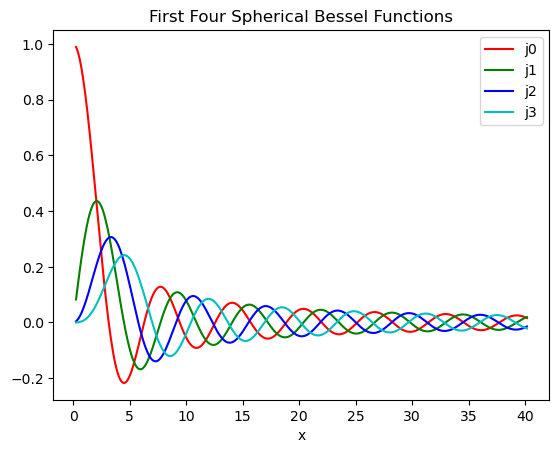

In [1]:
### Bessel.py, Notebook Version

import numpy as np
import matplotlib.pyplot as plt

Xmax = 40.25
Xmin = 0.25
step = 0.1   # Global class variables
order = 10; start = 50        # Plot j_order
j0=np.zeros((400),float)
j0=np.zeros((400),float)
j1=np.zeros((400),float)
j2=np.zeros((400),float)
j3=np.zeros((400),float)
xx=np.zeros((400),float)

def down (x, n, m):        # Method down, recurs downward
    j = np.zeros( (start  +  2), float)
    j[m+ 1] = j[m] = 1.   # Start with anything
    for k in range(m, 0,  - 1):
        j[k - 1] = ((2.*k + 1.)/x)*j[k]-j[k + 1]
    scale = (np.sin(x)/x)/j[0]  # Scale solution to known j[0]
    return j[n] * scale

i=0
for x in np.arange(Xmin, Xmax, step):
    xx[i]=x  
    j0[i]= down(x, 0, start)
    j1[i]=down(x,1,start)
    j2[i]=down(x,2,start)
    j3[i]=down(x,3,start)  
    i+=1   
lines=plt.plot(xx,j0,'r',xx,j1,'g',xx,j2,'b',xx,j3,'c')
plt.legend( ('j0','j1','j2','j3'),loc='upper right')
plt.title("First Four Spherical Bessel Functions")
plt.xlabel('x')
plt.show()
         

3.3  Experimental Error Investigation <a id="3.3"></a>

Numerical algorithms play a vital role in computational physics. Your
**problem** is to take a general algorithm and decide

1.  Does it converge?

2.  How precise are the converged results?

3.  How expensive (time-consuming) is it?

On first thought you may think, “What a dumb problem! All algorithms
converge if enough terms are used, and if you want more precision, then
use more terms.” Well, some algorithms may be asymptotic expansions that
just approximate a function in certain regions of parameter space and
converge only up to a point. Yet even if a uniformly convergent power
series is used as the algorithm, including more terms will decrease the
algorithmic error but will also increase the round-off errors. And
because round-off errors eventually diverge to infinity, the best we can
hope for is a “best” approximation. Good algorithms are good not only
because they are fast but also because they require fewer steps and thus
incur less round-off error.

Let us assume that an algorithm takes *N* steps to find a good answer.
As a rule of thumb, the approximation (algorithmic) error decreases
rapidly, often as the inverse power of the number of terms used:

$$\tag*{3.28}
    \epsilon_{\textrm app} \simeq   \frac{\alpha}{N^{\beta}}.$$

Here *α* and *β* are empirical constants that change for different
algorithms and may be only approximately constant, and even then only as
*N* → ∞. The fact that the error must fall off for large *N* is just a
statement that the algorithm converges.

In contrast to algorithmic error, round-off error grows slowly and somewhat
randomly with *N*. If the round-off errors in each step of the algorithm are not
correlated, then we know from previous discussion that we can model the
accumulation of error as a random walk with step size equal to the machine
precision *ϵ*<sub>*m*</sub>: 

    $$\begin{align}
\tag*{3.29}
    \epsilon_{\textrm ro} \simeq \sqrt{N} \epsilon_{m}.\end{align}$$
    
 This is the slow growth with *N* that we expect from round-off error.
The total error in a computation is the sum of the two types of errors:
    
$$\begin{align}
\tag*{3.30}
  &  \epsilon_{\textrm tot}   =     \epsilon_{\textrm app}
   + \epsilon_{\textrm ro}   \\
  &\epsilon_{\textrm tot}   \simeq  \frac{\alpha}{N^{\beta}} + \sqrt{N} \epsilon_{m}
  .\tag*{3.31}\end{align}$$
  
 For small *N* we expect the first term to be the larger of the two, but
as *N* grows it will be overcome by the growing round-off error.

![image](Figs/Fig3_3B.png) **Figure 3.3** A log-log plot of relative
error *versus* the number of points used for a numerical integration.
The ordinate value of $\sim 10^{-14}$ at the minimum indicates that
∼14 decimal places of precision are obtained before round-off error
begins to build up. Notice that while the round-off error does fluctuate
indicating a statistical aspect of error accumulation, on the average it
is increasing but more slowly than did the algorithm’s error decrease.

As an example, in Figure 3.3 we present a log-log plot of the relative error in
numerical integration using the Simpson integration rule
([Chapter 5](CP05.ipynb)). We use the log<sub>10</sub> of the relative error
because its negative tells us the number of decimal places of precision obtained.
[*Note:* Most computer languages use ln*x* = log<sub>*e*</sub>*x*. Yet
because *x* = *a*<sup>log<sub>*a*</sub>​*x*</sup>, we have
log<sub>10</sub>*x* = ln*x*/ln10.\] Let us assume 𝒜 is the exact answer and
*A*(*N*) the computed answer. If

$$\tag*{3.32}
 \frac{{\cal A} -A(N)} {{\cal A}    } \simeq  10^{-9}, \quad
 \mbox{then} \quad \log_{10}\left| \frac{{\cal A} -A(N)} { {\cal A} }\right|
  \simeq  -9.$$

We see in Figure 3.3 that the error does show a rapid decrease for small
*N*, consistent with an inverse power law (3.28). In this region the
algorithm is converging. As *N* keeps increasing, the error starts to
look somewhat erratic, with a slow increase on the average. In
accordance with (3.30), in this region round-off error has grown larger
than the approximation error and will continue to grow for increasing
*N*.Clearly then, the smallest total error will be obtained if we can
stop the calculation at the minimum near 10<sup>−14</sup>, that is, when
*ϵ*<sub>approx</sub> ≃ *ϵ*<sub>ro</sub>.

In realistic calculations you would not know the exact answer; after
all, if you did, then why would you bother with the computation?
However, you may know the exact answer for a similar calculation, and
you can use that similar calculation to perfect your numerical
technique. Alternatively, now that you understand how the total error in
a computation behaves, you should be able to look at a table or, better
yet, a graph like Figure 3.3, of your answer and deduce the manner in
which your algorithm is converging. Specifically, at some point you
should see that the mantissa of the answer changes only in the less
significant digits, with that place moving further to the right of the
decimal point as the calculation executes more steps. Eventually,
however, as the number of steps becomes even larger, round-off error
leads to a fluctuation in the less significant digits, with a gradual
move toward the decimal point. It is best to quit the calculation before
this occurs.

Based upon this understanding, an approach to obtaining the best
approximation is to deduce when your answer behaves like (3.30). To do
that, we call 𝒜 the exact answer and *A*(*N*) the computed answer after
*N* steps. We assume that for large enough values of *N*, the
approximation converges as

$$\tag*{3.33}
    A(N)  \simeq \mathcal{A} + \frac{\alpha}{N^{\beta}},$$

that is, that the round-off error term in (3.30) is still small. We then run our
computer program with 2*N* steps, which should give a better answer, and use
that answer to eliminate the unknown ${\cal A}$:

$$\tag*{3.34}
 A(N) - A(2N)  \simeq    \frac{\alpha}{N^{\beta}} .$$

To see if these assumptions are correct and determine what level of
precision is possible for the best choice of *N*, plot
log<sub>10</sub>|\[*A*(*N*)−*A*(2*N*)\]/*A*(2*N*)| <span>*versus*</span>
log<sub>10</sub>*N*, similar to what we have performed in Figure 3.3. If
you obtain a rapid straight-line drop off, then you know you are in the
region of convergence and can deduce a value for *β* from the slope. As
*N* gets larger, you should see the graph change from a straight-line
decrease to a slow increase as round-off error begins to dominate. A
good place to quit is before this. In any case, now you understand the
error in your computation and therefore have a chance to control it.

As an example of how different kinds of errors enter into a computation, we
assume we know the analytic form for the approximation and round-off errors:

$$\begin{align}
    \epsilon_{\textrm app} & \simeq \frac{1}{N^{2}},\tag*{3.35}\\
    \epsilon_{\textrm ro}  & \simeq \sqrt{N}\epsilon_m,
    \tag*{3.36}\\
   \Rightarrow \enspace     \epsilon_{\text{tot}} &= \epsilon_{\text{approx}} + \epsilon_{\text{ro}}\tag*{3.37}\\
    &  \simeq \frac{1}{N^{2}} +  \sqrt{N}\epsilon_m.\tag*{3.38}\end{align}$$
 The total error is then a minimum when
$$\begin{align}
\tag*{3.39}
    \frac{d\epsilon_{\text{tot}}}{dN} &= \frac{-2}{N^3} + \frac{1}{2}\frac{\epsilon_m}{\sqrt{N}} =
    0,\\
      \Rightarrow \enspace  N^{5/2} &=    \frac{4}{\epsilon_{m}}.\tag*{3.40}\end{align}$$
      
 For a double-precision calculation
(*ϵ*<sub>*m*</sub> ≃ 10<sup>−15</sup>), the minimum total error occurs
when

$$N^{5/2} \simeq \frac{4}{ 10^{-15}}
 \enspace \Rightarrow \enspace
N \simeq 1099 , \enspace \Rightarrow \enspace
    \epsilon_{\textrm tot}    \simeq        4 \times 10^{-6}.\tag*{3.41}$$

In this case most of the error is as a result of round-off and is not
approximation error.

Seeing that the total error is mainly round-off error ${\propto}\sqrt{N}$, an
obvious way to decrease the error is to use a smaller number of steps *N*. Let
us assume we do this by finding another algorithm that converges more rapidly
with *N*, for example, one with approximation error behaving like

$$\tag*{3.42}
    \epsilon_{\textrm app} \simeq \frac{2}{N^{4}} .$$
The total error is now
$$\tag*{3.43}
    \epsilon_{\textrm tot} = \epsilon_{\textrm ro}+\epsilon_{\textrm app} \simeq      \frac{2}{N^{4}} + \sqrt{N} \epsilon_{m}.$$

The number of points for minimum error is found as before:

$$\tag*{3.44}
    \frac{d\epsilon_{\text{tot}}}{dN} = 0         \enspace   \Rightarrow \enspace  N^{{9}/{2}}
  \enspace \Rightarrow \enspace        N \simeq 67  \enspace \Rightarrow \enspace
    \epsilon_{\text{tot}}       \simeq 9
\times 10^{-7}.$$

The error is now smaller by a factor of 4, with only 1/16 as many steps
needed. Subtle are the ways of the computer. In this case the better
algorithm is quicker and, by using fewer steps, produces less round-off
error.

**Exercise:** Estimate the error now for a double-precision calculation.

### 3.3.1  Error Assessment<a id="3.3.1"></a>

![image](Figs/Fig3_4.png) **Figure 3.4** The error in the summation of
the series for *e*<sup>−*x*</sup> *versus* *N* for various *x* values.
The values of *x* increase vertically for each curve. Note that a
negative initial slope corresponds to decreasing error with *N*, and
that the dip corresponds to a rapid convergence followed by a rapid
increase in error. (Courtesy of J. Wiren.)

In § 2.5 we have already discussed the Taylor expansion of sin*x*: 

$$\tag*{3.45}
\sin(x) = x - \frac{x^{3}}{3 !} + \frac{x^{5}}{5!} -
\frac{x^{7}}{7!} +   \cdots =\sum_{n=1}^\infty
\frac{(-1)^{n-1}x^{2n-1}} { (2n-1)!}.$$

We now extend that discussion with errors in mind . The series (3.45)
converges in the mathematical sense for all values of *x*. Accordingly,
a reasonable algorithm to compute the sin(*x*) might be

$$\tag*{3.46}
    \sin(x)  \simeq \sum_{n=1}^N  \frac{(-1)^{n-1}x^{2n-1}} { (2n-1)!}.$$

1.  Write a program that calculates sin(*x*) as the finite sum (3.46).
    (If you already did this in [Chapter 2](CP02.ipynb), then you may
    reuse that program and its results here. But remember, you should
    not be using factorials in the algorithm.)

2.  Calculate your series for *x* ≤ 1 and compare it to the built-in
    function `Math.sin(x)` (you may assume that the built-in function
    is exact). Stop your summation at an *N* value for which the next
    term in the series will be no more than 10<sup>−7</sup> of the sum
    up to that point,[[xml]](http://physics.oregonstate.edu/~rubin/Books/CPbook/eBook/xml/3.47.xml)

    $$\tag*{3.47}
    \frac{|(-1)^N x^{2N+1}|} { (2N-1)!} \le  10^{-7}  \left
    |\sum_{n=1}^N \frac{(-1)^{n-1}x^{2n-1}} { (2n-1)!}\right|.$$

3.  Examine the terms in the series for *x* ≃ 3*π* and observe the
    significant subtractive cancellations that occur when large terms
    add together to give small answers. \[Do not use the identity
    sin(*x* + 2*π*)=sin*x* to reduce the value of *x* in the series.\]
    In particular, print out the near-perfect cancellation around
    *n* ≃ *x*/2.

4.  See if better precision is obtained by using trigonometric
    identities to keep 0 ≤ *x* ≤ *π*.

5.  By progressively increasing *x* from 1 to 10, and then from 10 to
    100, use your program to determine experimentally when the series
    starts to lose accuracy and when it no longer converges.

6.  Make a series of graphs of the error *versus* *N* for different
    values of *x* . You should get curves similar to those
    in Figure 3.4.

Because this series summation is such a simple, correlated process, the
round-off error does not accumulate randomly as it might for a more
complicated computation, and we do not obtain the error behavior (3.33).
We will see the predicted error behavior when we examine integration
rules in [Chapter 5](CP05.ipynb).